<a href="https://colab.research.google.com/github/contactvarun2002/Web-mining-/blob/main/Web_mining_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Quantum AI-driven web usage mining for web behavior analytics and learning style prediction in smart learning**

In [ ]:
#Quantum AI-driven web usage mining for web behavior analytics and learning style prediction in smart learning
#import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import math, os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.svm import SVC
from dataclasses import dataclass
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [ ]:
#uploaded E-learning student interactions dataset.csv
from google.colab import files
uploaded = files.upload()

Saving E-learning student interactions dataset.xlsx - E-learning student interactions dataset.xls.csv to E-learning student interactions dataset.xlsx - E-learning student interactions dataset.xls.csv


In [ ]:
import pandas as pd
df = pd.read_csv("E-learning student interactions dataset.xls")
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (14101, 21)
                             student_id             name   age  \
0  9c19eea1-3955-4b62-90c4-379f6cd2edf7      Diana Black  40.0   
1  aa75e84a-1e26-42e1-b4ee-fba65d1c52f6     Peter Wright  31.0   
2  b1eeae84-f4b3-489a-bf2b-5d290a690d80  Elizabeth Cohen  19.0   
3  41719f01-5446-4783-81a5-18e52ae15ac4      Miguel Owen  40.0   
4  187ac969-cdb5-433f-a173-4612406681a1     Kevin Watson  49.0   

  experience_level learning_style  \
0         Beginner    Kinesthetic   
1     Intermediate         Visual   
2     Intermediate         Visual   
3         Advanced         Visual   
4         Advanced       Auditory   

                                           interests  \
0  Penetration Testing, React, Natural Language P...   
1                  Serverless Architecture, Big Data   
2            Statistics, JavaScript, Neural Networks   
3                             Ethical Hacking, React   
4                        Computer Vision, HTML & CSS   

                

In [ ]:
display(df.head(5))

,student_id,name,age,experience_level,learning_style,interests,course_id,course_name,category,difficulty_level,...,num_reviews,time_spent_on_course,completion_status,video_id,video_topic,video_duration,time_watched,skip_count,pause_count,disengagement_score
0,9c19eea1-3955-4b62-90c4-379f6cd2edf7,Diana Black,40.0,Beginner,Kinesthetic,"Penetration Testing, React, Natural Language P...",5a047616-93de-4000-af53-3b9b71f38925,Certified Ethical Hacker (CEH),Cybersecurity,Beginner,...,473.0,136.0,True,bf694642-ec34-4e49-891b-cceef145206d,Penetration Testing,225.0,194.0,0.0,2.0,0.12
1,aa75e84a-1e26-42e1-b4ee-fba65d1c52f6,Peter Wright,31.0,Intermediate,Visual,"Serverless Architecture, Big Data",fa6c853d-7ffe-490c-9bfb-ad09f28de94a,Statistics for ML,Data Science,Intermediate,...,36.0,234.0,False,577ea2d0-967d-4ba0-8c05-0c6caca5c71d,Machine Learning,467.0,178.0,4.0,9.0,0.60
2,b1eeae84-f4b3-489a-bf2b-5d290a690d80,Elizabeth Cohen,19.0,Intermediate,Visual,"Statistics, JavaScript, Neural Networks",ed8e6fb3-64f5-4e56-bdb6-dbf4e96ffe7a,Artificial Intelligence A-Z,AI,Intermediate,...,250.0,552.0,False,7fb6d538-5e91-40de-93fd-dd91dd75f5b8,Reinforcement Learning,338.0,87.0,8.0,3.0,0.71
3,41719f01-5446-4783-81a5-18e52ae15ac4,Miguel Owen,40.0,Advanced,Visual,"Ethical Hacking, React",e6d4d6f3-46f9-4671-95e1-67a63fe10be4,Advanced Penetration Testing,Cybersecurity,Advanced,...,335.0,177.0,True,9292f8ea-e457-462d-bce2-0b0ab564f953,Penetration Testing,51.0,32.0,2.0,2.0,0.32
4,187ac969-cdb5-433f-a173-4612406681a1,Kevin Watson,49.0,Advanced,Auditory,"Computer Vision, HTML & CSS",bc9ea229-ee78-4c25-acde-ef33045eadcd,Computer Vision with OpenCV,AI,Advanced,...,240.0,320.0,False,eae20545-77db-4d00-8f0e-2a0988bdd494,Computer Vision,499.0,271.0,7.0,9.0,0.55


In [ ]:
display(df.head(5))

,student_id,name,age,experience_level,learning_style,interests,course_id,course_name,category,difficulty_level,...,num_reviews,time_spent_on_course,completion_status,video_id,video_topic,video_duration,time_watched,skip_count,pause_count,disengagement_score
0,9c19eea1-3955-4b62-90c4-379f6cd2edf7,Diana Black,40.0,Beginner,Kinesthetic,"Penetration Testing, React, Natural Language P...",5a047616-93de-4000-af53-3b9b71f38925,Certified Ethical Hacker (CEH),Cybersecurity,Beginner,...,473.0,136.0,True,bf694642-ec34-4e49-891b-cceef145206d,Penetration Testing,225.0,194.0,0.0,2.0,0.12
1,aa75e84a-1e26-42e1-b4ee-fba65d1c52f6,Peter Wright,31.0,Intermediate,Visual,"Serverless Architecture, Big Data",fa6c853d-7ffe-490c-9bfb-ad09f28de94a,Statistics for ML,Data Science,Intermediate,...,36.0,234.0,False,577ea2d0-967d-4ba0-8c05-0c6caca5c71d,Machine Learning,467.0,178.0,4.0,9.0,0.60
2,b1eeae84-f4b3-489a-bf2b-5d290a690d80,Elizabeth Cohen,19.0,Intermediate,Visual,"Statistics, JavaScript, Neural Networks",ed8e6fb3-64f5-4e56-bdb6-dbf4e96ffe7a,Artificial Intelligence A-Z,AI,Intermediate,...,250.0,552.0,False,7fb6d538-5e91-40de-93fd-dd91dd75f5b8,Reinforcement Learning,338.0,87.0,8.0,3.0,0.71
3,41719f01-5446-4783-81a5-18e52ae15ac4,Miguel Owen,40.0,Advanced,Visual,"Ethical Hacking, React",e6d4d6f3-46f9-4671-95e1-67a63fe10be4,Advanced Penetration Testing,Cybersecurity,Advanced,...,335.0,177.0,True,9292f8ea-e457-462d-bce2-0b0ab564f953,Penetration Testing,51.0,32.0,2.0,2.0,0.32
4,187ac969-cdb5-433f-a173-4612406681a1,Kevin Watson,49.0,Advanced,Auditory,"Computer Vision, HTML & CSS",bc9ea229-ee78-4c25-acde-ef33045eadcd,Computer Vision with OpenCV,AI,Advanced,...,240.0,320.0,False,eae20545-77db-4d00-8f0e-2a0988bdd494,Computer Vision,499.0,271.0,7.0,9.0,0.55


Data Processing

In [ ]:

# DATA PREPROCESSING PIPELINE FOR E-LEARNING CLICKSTREAM DATA
# Includes:
# 1. Data Cleaning
# 2. Session Identification
# 3. User Behaviour Normalization
# 4. Encoding
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    StandardScaler,
    RobustScaler
)

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

#LOAD DATASET
# place with your dataset path
DATA_PATH = "E-learning student interactions dataset.xlsx - E-learning student interactions dataset.xls.csv"

df = pd.read_csv(DATA_PATH)

print("DATASET LOADED SUCCESSFULLY")

print("\nDataset Shape :", df.shape)

print("\nColumns:")
print(df.columns.tolist())

# STEP 1 : DATA CLEANING

initial_rows = len(df)

df.drop_duplicates(inplace=True)

final_rows = len(df)

print(f"Duplicate Rows Removed : {initial_rows-final_rows}")

# Convert timestamp column
# Replace 'timestamp' with your actual timestamp column name
# NOTE: The 'timestamp' column was not found in the dataset.
# The following lines have been commented out to prevent a KeyError.
# Please update 'TIMESTAMP_COL' to a valid column name if you have one,
# or uncomment and adjust if a timestamp column is added later.

TIMESTAMP_COL = None # Set to None as column is missing

# df[TIMESTAMP_COL] = pd.to_datetime(
#     df[TIMESTAMP_COL],
#     errors='coerce'
# )

# # Remove invalid timestamps
# df = df[df[TIMESTAMP_COL].notna()]

# Explicitly convert columns to numeric where appropriate
# This addresses the issue where numerical columns might be read as 'object' type
numeric_candidate_cols = [
    'age', 'ratings', 'num_reviews', 'time_spent_on_course',
    'video_duration', 'time_watched', 'skip_count', 'pause_count', 'disengagement_score'
]

for col in numeric_candidate_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Detect numerical columns
numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Remove ID columns from numerical list
remove_cols = [
    'user_id',
    'session_id',
    'student_id' # Adding student_id as it's an identifier, not a measurement
]

numerical_cols = [
    col for col in numerical_cols
    if col not in remove_cols
]


# Detect categorical columns
categorical_cols = df.select_dtypes(
    include=['object']
).columns.tolist()

# Add 'name', 'course_id', 'video_id' to categorical_cols if they are not already there and should be treated as categorical.
# These are identifiers or nominal categories that might have been converted to numeric if they contained only numbers before.
categorical_candidate_cols = ['name', 'course_id', 'video_id']
for col in categorical_candidate_cols:
    if col in df.columns and col not in categorical_cols:
        categorical_cols.append(col)

# Remove timestamp from categorical if TIMESTAMP_COL is a string (a valid column name)
categorical_cols = [
    col for col in categorical_cols
    if TIMESTAMP_COL is None or col != TIMESTAMP_COL
]

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

# Missing Value Handling
print("\nHandling Missing Values...")

# Numerical missing values
num_imputer = SimpleImputer(strategy='median')

if len(numerical_cols) > 0:
    df[numerical_cols] = num_imputer.fit_transform(
        df[numerical_cols]
    )

# Categorical missing values
cat_imputer = SimpleImputer(strategy='most_frequent')

if len(categorical_cols) > 0:
    df[categorical_cols] = cat_imputer.fit_transform(
        df[categorical_cols]
    )

print("Missing Values Handled Successfully")

# Outlie Removal using IQR

print("\nRemoving Outliers Using IQR Method...")

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

print("Outliers Removed Successfully")

print("\nDataset Shape After Cleaning :", df.shape)

# STEP 2 : SESSION IDENTIFICATION
# Replace with your actual user column
USER_COL = 'user_id' # This column was not in the original dataset and caused the previous 'remove_cols' to not remove anything relevant.
# The 'student_id' column is the actual user identifier.

# Updating USER_COL to 'student_id' based on available columns
USER_COL = 'student_id'

# Sort values - This step also relies on TIMESTAMP_COL which is missing.
# If a timestamp column is identified, this line should be uncommented and updated.
# if TIMESTAMP_COL is not None:
#     df = df.sort_values(
#         by=[USER_COL, TIMESTAMP_COL]
#     )

#
# Time difference between events

DATASET LOADED SUCCESSFULLY

Dataset Shape : (42303, 21)

Columns:
['student_id', 'name', 'age', 'experience_level', 'learning_style', 'interests', 'course_id', 'course_name', 'category', 'difficulty_level', 'ratings', 'num_reviews', 'time_spent_on_course', 'completion_status', 'video_id', 'video_topic', 'video_duration', 'time_watched', 'skip_count', 'pause_count', 'disengagement_score']
Duplicate Rows Removed : 18866

Numerical Columns:
['age', 'ratings', 'num_reviews', 'time_spent_on_course', 'video_duration', 'time_watched', 'skip_count', 'pause_count', 'disengagement_score']

Categorical Columns:
['student_id', 'name', 'experience_level', 'learning_style', 'interests', 'course_id', 'course_name', 'category', 'difficulty_level', 'completion_status', 'video_id', 'video_topic']

Handling Missing Values...
Missing Values Handled Successfully

Removing Outliers Using IQR Method...
Outliers Removed Successfully

Dataset Shape After Cleaning : (20233, 21)


In [ ]:
# STEP 3 : USER BEHAVIOUR NORMALIZATION
print("USER BEHAVIOUR NORMALIZATION")

# FEATURE NORMALIZATION

# Note: The original 'time_spent', 'click_count', 'scroll_depth' columns are not present.
# These blocks will be skipped due to the 'if' condition.
# If you have equivalent columns, update the names here.
if 'time_spent_on_course' in df.columns:
    # Ensure column is numeric and handle any remaining NaNs
    df['time_spent_on_course'] = pd.to_numeric(df['time_spent_on_course'], errors='coerce')
    df['time_spent_on_course'].fillna(df['time_spent_on_course'].median(), inplace=True)
    df['normalized_time_spent'] = (
        df['time_spent_on_course'] /
        (df['time_spent_on_course'].max() + 1e-6)
    )

# if 'click_count' in df.columns:
#     df['normalized_clicks'] = (
#         df['click_count'] /
#         (df['click_count'].max() + 1e-6)
#     )

# if 'scroll_depth' in df.columns:
#     df['normalized_scroll_depth'] = (
#         df['scroll_depth'] /
#         (df['scroll_depth'].max() + 1e-6)
#     )

# USER AGGREGATION
# Update USER_COL to 'student_id' as 'user_id' is not in the dataset
USER_COL = 'student_id'

# Aggregate by 'student_id' and use 'time_spent_on_course' as a proxy for session duration
user_behavior = df.groupby(USER_COL).agg({
    'time_spent_on_course':'mean' # Use an existing relevant column
}).reset_index()

user_behavior.rename(
    columns={
        'time_spent_on_course': # Rename to reflect the aggregated column
        'avg_time_spent_on_course'
    },
    inplace=True
)

df = df.merge(
    user_behavior,
    on=USER_COL,
    how='left'
)
# ROBUST SCALING
behavior_cols = []

# Update possible_cols to reflect existing behavioral columns in the dataset
possible_cols = [
    'time_spent_on_course',
    'time_watched',
    'skip_count',
    'pause_count',
    'disengagement_score',
    'avg_time_spent_on_course' # Add the newly created aggregated column
]

for col in possible_cols:
    if col in df.columns:
        behavior_cols.append(col)

print("\nBehavior Columns:")
print(behavior_cols)

scaler = RobustScaler()

if len(behavior_cols) > 0:
    # Ensure all behavior columns are numeric before scaling
    for col in behavior_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(df[col].median(), inplace=True)

    df[behavior_cols] = scaler.fit_transform(
        df[behavior_cols]
    )

print("Behaviour Normalization Completed")


# STEP 4 : ENCODING
print("\nSTEP 4 : ENCODING")

encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

    encoders[col] = encoder

print("Encoding Completed")


# TEMPORAL FEATURES
print("\nTEMPORAL FEATURE EXTRACTION")

# The TIMESTAMP_COL was set to None in the previous cell as it was not found.
# This section is commented out to prevent errors.
# If a timestamp column exists in your dataset, please update TIMESTAMP_COL
# in the previous cell and uncomment this section.
# df['hour'] = df[TIMESTAMP_COL].dt.hour
# df['day'] = df[TIMESTAMP_COL].dt.day
# df['month'] = df[TIMESTAMP_COL].dt.month
# df['weekday'] = df[TIMESTAMP_COL].dt.weekday

# df['is_weekend'] = df['weekday'].apply(
#     lambda x: 1 if x >= 5 else 0
# )

print("Temporal Features (Skipped: No timestamp column found)")

# FINAL DATASET
print("\nFINAL DATASET")

print("\nFinal Shape :", df.shape)

print("\nSample Rows:")
print(df.head())

# SAVE DOWNLOADABLE CSV FILE
OUTPUT_FILE = "preprocessed_dataset.csv"

df.to_csv(
    OUTPUT_FILE,
    index=False
)
files.download("preprocessed_dataset.csv")
print("PREPROCESSED CSV FILE GENERATED SUCCESSFULLY")
print(f"\nSaved File Name : {OUTPUT_FILE}")

print("""
DOWNLOADABLE OUTPUT GENERATED:
-> preprocessed_dataset.csv

This file contains:
✓ Cleaned Data
✓ Session IDs
✓ Normalized Behaviour
✓ Encoded Features
✓ Temporal Features
✓ Ready for:
   - ClickstreamGPT
   - SASRec
   - ConSL
   - MS-HHO
   - DS-QNN
""")

# OPTIONAL TRAIN TEST SPLIT
TARGET_COLUMN = 'target'   # change if needed

if TARGET_COLUMN in df.columns:

    X = df.drop(columns=[TARGET_COLUMN])
    y = df[TARGET_COLUMN]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print("\nTrain Shape :", X_train.shape)
    print("Test Shape  :", X_test.shape)

USER BEHAVIOUR NORMALIZATION

Behavior Columns:
['time_spent_on_course', 'time_watched', 'skip_count', 'pause_count', 'disengagement_score']
Behaviour Normalization Completed

STEP 4 : ENCODING
Encoding Completed

TEMPORAL FEATURE EXTRACTION
Temporal Features (Skipped: No timestamp column found)

FINAL DATASET

Final Shape : (23437, 24)

Sample Rows:
   student_id  name  age  experience_level  learning_style  interests  \
0        3434  1415   44                 1               1       3371   
1        3752  4175   26                 3               3       3759   
2        3905  1580    2                 3               3       4017   
3        1480  3807   44                 0               3       1402   
4         537  3003   62                 0               0        605   

   course_id  course_name  category  difficulty_level  ...  video_id  \
0       4948          276         3                 1  ...     10341   
1      13525         1519         4                 2  ...      

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PREPROCESSED CSV FILE GENERATED SUCCESSFULLY

Saved File Name : preprocessed_dataset.csv

DOWNLOADABLE OUTPUT GENERATED:
-> preprocessed_dataset.csv

This file contains:
✓ Cleaned Data
✓ Session IDs
✓ Normalized Behaviour
✓ Encoded Features
✓ Temporal Features
✓ Ready for:
   - ClickstreamGPT
   - SASRec
   - ConSL
   - MS-HHO
   - DS-QNN



behavioural feature extraction



In [ ]:

# HYBRID BEHAVIORAL FEATURE EXTRACTION MODULE
# ClickstreamGPT + SASRec + ConSL
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Dense,
    Dropout,
    LSTM,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Add
)

from tensorflow.keras.models import Model
# LOAD DATASET
dataset_path = "preprocessed_dataset.csv"

data = pd.read_csv(dataset_path)

# BASIC PREPARATION
user_column      = "student_id" # Changed from "user_id" to "student_id" based on available data
item_column      = "course_id"  # Using 'course_id' as a proxy for 'page' or item
# timestamp_column = "timestamp" # Commented out as 'timestamp' column does not exist

# The following lines are commented out as 'timestamp' column does not exist in the preprocessed data.
# If a suitable timestamp column is present, uncomment and update 'timestamp_column' accordingly.
# data[timestamp_column] = pd.to_datetime(
#     data[timestamp_column],
#     errors="coerce"
# )

# data = data.dropna(
#     subset=[timestamp_column]
# )

# If a timestamp column is added later, ensure to sort by it.
# For now, sorting by user_column only.
data = data.sort_values(
    by=[user_column]
).reset_index(drop=True)

# ITEM ENCODING
item_encoder = LabelEncoder()

data["item_index"] = item_encoder.fit_transform(
    data[item_column].astype(str)
)

total_items = data["item_index"].nunique()

# USER SEQUENCE GENERATION
sequence_length = 25

grouped_sequences = data.groupby(user_column)[
    "item_index"
].apply(list)

prepared_sequences = []

for seq in grouped_sequences:

    if len(seq) >= sequence_length:
        prepared_sequences.append(
            seq[-sequence_length:]
        )

    else:
        padding_size = sequence_length - len(seq)

        padded_sequence = (
            [0] * padding_size
        ) + seq

        prepared_sequences.append(
            padded_sequence
        )

prepared_sequences = np.array(
    prepared_sequences
)

# CLICKSTREAMGPT MODULE
# LONG-RANGE BEHAVIORAL MODELING
click_input_layer = Input(
    shape=(sequence_length,)
)

click_embedding = Embedding(
    input_dim=total_items + 1,
    output_dim=96,
    mask_zero=False
)(
    click_input_layer
)

click_lstm_forward = LSTM(
    128,
    return_sequences=True
)(
    click_embedding
)

click_lstm_backward = LSTM(
    128,
    go_backwards=True,
    return_sequences=True
)(
    click_embedding
)

click_merged = Add()([
    click_lstm_forward,
    click_lstm_backward
])

click_merged = LayerNormalization()(
    click_merged
)

click_merged = Dropout(0.25)(
    click_merged
)

click_temporal_context = LSTM(
    64,
    return_sequences=False
)(
    click_merged
)

click_dense_representation = Dense(
    128,
    activation="relu"
)(
    click_temporal_context
)

click_dense_representation = Dense(
    64,
    activation="relu"
)(
    click_dense_representation
)

ClickstreamGPT = Model(
    click_input_layer,
    click_dense_representation
)

clickstream_features = ClickstreamGPT.predict(
    prepared_sequences,
    verbose=0
)

# SASRec MODULE
# SELF-ATTENTION SEQUENTIAL MODELING
sasrec_input = Input(shape=(sequence_length,)
)

sasrec_embedding = Embedding(
    input_dim=total_items + 1,
    output_dim=96
)(
    sasrec_input
)

self_attention_block = MultiHeadAttention(
    num_heads=4,
    key_dim=64,
    dropout=0.2
)(
    sasrec_embedding,
    sasrec_embedding
)

attention_skip_connection = Add()([
    sasrec_embedding,
    self_attention_block
])

attention_normalization = LayerNormalization()(
    attention_skip_connection
)

attention_pooling = GlobalAveragePooling1D()(
    attention_normalization
)

sasrec_dense = Dense(
    128,
    activation="relu"
)(
    attention_pooling
)

sasrec_dense = Dropout(0.2)(
    sasrec_dense
)

sasrec_dense = Dense(
    64,
    activation="relu"
)(
    sasrec_dense
)

SASRec = Model(
    sasrec_input,
    sasrec_dense
)

sasrec_features = SASRec.predict(
    prepared_sequences,
    verbose=0
)


# ConSL MODULE
# CONTRASTIVE BEHAVIORAL REPRESENTATION LEARNING
feature_scaler = StandardScaler()

normalized_clickstream = feature_scaler.fit_transform(
    clickstream_features
)

normalized_sasrec = feature_scaler.fit_transform(
    sasrec_features
)

behavior_similarity_matrix = cosine_similarity(
    normalized_clickstream,
    normalized_sasrec
)

pca_projection = PCA(
    n_components=64,
    random_state=42
)

consl_features = pca_projection.fit_transform(
    behavior_similarity_matrix
)

# HYBRID FEATURE FUSION
hybrid_behavioral_embedding = np.concatenate(
    [
        clickstream_features,
        sasrec_features,
        consl_features
    ],
    axis=1
)

# FINAL FEATURE DATAFRAME
feature_names = []

for feature_id in range(
    hybrid_behavioral_embedding.shape[1]
):

    feature_names.append(
        f"behavior_feature_{feature_id+1}"
    )

behavior_feature_dataset = pd.DataFrame(
    hybrid_behavioral_embedding,
    columns=feature_names
)

behavior_feature_dataset[user_column] = list(
    grouped_sequences.index
)

# OPTIONAL TEMPORAL STATISTICS
session_statistics = data.groupby(
    user_column
).agg({
    "item_index": "count"
}).reset_index()

session_statistics.columns = [
    user_column,
    "total_interactions"
]

behavior_feature_dataset = behavior_feature_dataset.merge(
    session_statistics,
    on=user_column,
    how="left"
)

# SAVE FINAL FEATURE DATAFRAME
output_file_name = "behavioral_feature_embeddings.csv"

behavior_feature_dataset.to_csv(
    output_file_name,
    index=False
)
# GOOGLE COLAB DOWNLOAD SUPPORT
try:

    from google.colab import files

    files.download(output_file_name)

except:
    pass
# FINAL FEATURE MATRIX
behavior_feature_dataset.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,behavior_feature_1,behavior_feature_2,behavior_feature_3,behavior_feature_4,behavior_feature_5,behavior_feature_6,behavior_feature_7,behavior_feature_8,behavior_feature_9,behavior_feature_10,...,behavior_feature_185,behavior_feature_186,behavior_feature_187,behavior_feature_188,behavior_feature_189,behavior_feature_190,behavior_feature_191,behavior_feature_192,student_id,total_interactions
0,0.123105,0.415717,0.000000,0.000000,0.149128,0.144193,0.108217,0.0,0.040293,0.0,...,1.353472e-06,-3.151286e-06,0.000001,3.812302e-07,1.028781e-07,-0.000002,4.317887e-06,-6.900333e-08,0,2
1,0.040849,0.451923,0.000000,0.069492,0.137990,0.159290,0.103247,0.0,0.052189,0.0,...,8.045711e-06,8.467152e-06,0.000001,-1.272801e-06,-5.767533e-06,-0.000007,-4.389557e-06,1.100326e-05,1,3
2,0.092047,0.337870,0.012938,0.125942,0.166409,0.047767,0.216810,0.0,0.165575,0.0,...,4.599346e-06,-8.425220e-07,-0.000004,4.276533e-06,4.741492e-06,-0.000009,-5.112694e-06,4.396900e-06,2,6
3,0.110269,0.465335,0.000000,0.008222,0.109534,0.183760,0.102665,0.0,0.042272,0.0,...,-2.830078e-06,-7.134866e-06,0.000006,-9.840375e-06,-4.734577e-07,-0.000006,1.560252e-06,7.726147e-06,3,1
4,0.140656,0.480080,0.000000,0.047534,0.119015,0.211249,0.099556,0.0,0.035382,0.0,...,7.627632e-07,2.936367e-06,0.000002,-7.349286e-06,-3.270360e-06,-0.000002,-2.639049e-07,-4.606888e-07,4,2


Clustering using MS-HHO

In [ ]:

# MULTI-SURROGATE HARRIS HAWKS OPTIMIZATION (MS-HHO)
# LEARNER CLUSTERING FRAMEWORK
# INPUT  : behavioral_feature_embeddings.csv
# OUTPUT : clustered_learners_output.csv


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.metrics.pairwise import euclidean_distances

from sklearn.svm import SVR

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

# RANDOM SEED

np.random.seed(42)

# MANUAL CSV UPLOAD

try:

    from google.colab import files

    uploaded = files.upload()

    uploaded_file_name = list(uploaded.keys())[0]

    dataset_path = uploaded_file_name

except:

    dataset_path = "behavioral_feature_embeddings.csv"

# LOAD DATASET

feature_dataset = pd.read_csv(dataset_path)

# TARGET COLUMN

TARGET_COLUMN = "learning_style"

# ID COLUMNS

possible_id_columns = [
    "user_id",
    "student_id",
    "learner_id"
]

existing_id_columns = [
    col for col in possible_id_columns
    if col in feature_dataset.columns
]

# REMOVE NON-NUMERIC COLUMNS

ignore_columns = existing_id_columns.copy()

if TARGET_COLUMN in feature_dataset.columns:
    ignore_columns.append(TARGET_COLUMN)

feature_columns = []

for col in feature_dataset.columns:

    if col in ignore_columns:
        continue

    if pd.api.types.is_numeric_dtype(
        feature_dataset[col]
    ):
        feature_columns.append(col)

# FEATURE MATRIX

X = feature_dataset[
    feature_columns
].copy()

# HANDLE MISSING VALUES

X = X.fillna(
    X.median(numeric_only=True)
)

# NORMALIZATION

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# MS-HHO PARAMETERS

population_size = 20

maximum_iterations = 50

number_of_clusters = 5

dimension = X_scaled.shape[1]

lower_bound = -1

upper_bound = 1

# INITIAL HAWK POPULATION

hawk_population = np.random.uniform(

    lower_bound,
    upper_bound,

    (
        population_size,
        dimension
    )
)

# FITNESS FUNCTION

def clustering_fitness(solution_vector):

    weighted_features = (
        X_scaled * solution_vector
    )

    kmeans_model = KMeans(

        n_clusters=number_of_clusters,

        random_state=42,

        n_init=20
    )

    cluster_labels = kmeans_model.fit_predict(
        weighted_features
    )

    silhouette = silhouette_score(
        weighted_features,
        cluster_labels
    )

    davies = davies_bouldin_score(
        weighted_features,
        cluster_labels
    )

    calinski = calinski_harabasz_score(
        weighted_features,
        cluster_labels
    )

    intra_cluster_distance = np.mean(

        np.min(

            euclidean_distances(
                weighted_features,
                kmeans_model.cluster_centers_
            ),

            axis=1
        )
    )

    fitness_value = (

        (1.5 * silhouette)

        +

        (0.002 * calinski)

        -

        (0.8 * davies)

        -

        (0.5 * intra_cluster_distance)
    )

    return fitness_value

# INITIAL FITNESS

fitness_scores = np.array([

    clustering_fitness(hawk)

    for hawk in hawk_population
])

best_index = np.argmax(
    fitness_scores
)

best_solution = hawk_population[
    best_index
].copy()

best_fitness = fitness_scores[
    best_index
]

fitness_history = []

# SURROGATE MODEL PREPARATION

surrogate_X = hawk_population.copy()

surrogate_y = fitness_scores.copy()

# POLYNOMIAL REGRESSION SURROGATE

poly_transform = PolynomialFeatures(
    degree=2
)

poly_X = poly_transform.fit_transform(
    surrogate_X
)

polynomial_model = LinearRegression()

polynomial_model.fit(
    poly_X,
    surrogate_y
)

# SVR SURROGATE

svr_model = SVR(
    kernel='rbf',
    C=10,
    gamma='scale'
)

svr_model.fit(
    surrogate_X,
    surrogate_y
)

# GPR SURROGATE

gpr_kernel = RBF(
    length_scale=1.0
)

gpr_model = GaussianProcessRegressor(
    kernel=gpr_kernel,
    alpha=1e-6
)

gpr_model.fit(
    surrogate_X,
    surrogate_y
)

# MS-HHO OPTIMIZATION LOOP

for iteration in range(maximum_iterations):

    escape_energy = 2 * (
        1 - (
            iteration / maximum_iterations
        )
    )

    for hawk_index in range(population_size):

        current_hawk = hawk_population[
            hawk_index
        ].copy()

        random_energy = np.random.uniform(
            -1,
            1
        )

        escaping_strength = (
            escape_energy * random_energy
        )

        random_probability = np.random.rand()

        # --------------------------------------------------------------------

        if abs(escaping_strength) >= 1:

            random_hawk_index = np.random.randint(
                population_size
            )

            random_hawk = hawk_population[
                random_hawk_index
            ]

            updated_position = (

                random_hawk

                -

                np.random.rand(dimension)

                *

                abs(

                    random_hawk

                    -

                    2 * np.random.rand(dimension)

                    * current_hawk
                )
            )

        else:

            if random_probability >= 0.5:

                updated_position = (

                    best_solution

                    -

                    escaping_strength

                    *

                    abs(
                        best_solution
                        -
                        current_hawk
                    )
                )

            else:

                jump_strength = 2 * (
                    1 - np.random.rand()
                )

                updated_position = (

                    best_solution

                    -

                    escaping_strength

                    *

                    abs(

                        jump_strength
                        *
                        best_solution

                        -

                        current_hawk
                    )
                )

        # --------------------------------------------------------------------

        updated_position = np.clip(

            updated_position,

            lower_bound,

            upper_bound
        )

        # SURROGATE ESTIMATION


        polynomial_prediction = polynomial_model.predict(

            poly_transform.transform(
                [updated_position]
            )

        )[0]

        svr_prediction = svr_model.predict(
            [updated_position]
        )[0]

        gpr_prediction = gpr_model.predict(
            [updated_position]
        )[0]

        surrogate_fitness = np.mean([

            polynomial_prediction,

            svr_prediction,

            gpr_prediction
        ])

        # ACTUAL FITNESS

        actual_fitness = clustering_fitness(
            updated_position
        )

        if actual_fitness > fitness_scores[hawk_index]:

            hawk_population[
                hawk_index
            ] = updated_position

            fitness_scores[
                hawk_index
            ] = actual_fitness

        if actual_fitness > best_fitness:

            best_solution = updated_position.copy()

            best_fitness = actual_fitness

    fitness_history.append(
        best_fitness
    )

# FINAL OPTIMIZED FEATURE SPACE

optimized_feature_space = (
    X_scaled * best_solution
)

# FINAL CLUSTERING

final_cluster_model = KMeans(

    n_clusters=number_of_clusters,

    random_state=42,

    n_init=25
)

cluster_labels = final_cluster_model.fit_predict(
    optimized_feature_space
)

# CLUSTER METRICS

silhouette_result = silhouette_score(
    optimized_feature_space,
    cluster_labels
)

davies_result = davies_bouldin_score(
    optimized_feature_space,
    cluster_labels
)

calinski_result = calinski_harabasz_score(
    optimized_feature_space,
    cluster_labels
)

# t-SNE PROJECTION

tsne_projection = TSNE(

    n_components=2,

    perplexity=30,

    learning_rate='auto',

    init='random',

    random_state=42
)

embedded_clusters = tsne_projection.fit_transform(
    optimized_feature_space
)

# FINAL OUTPUT DATASET

cluster_output = feature_dataset.copy()

cluster_output["cluster_label"] = cluster_labels

cluster_output["optimized_fitness"] = best_fitness

cluster_output["tsne_dimension_1"] = embedded_clusters[:,0]

cluster_output["tsne_dimension_2"] = embedded_clusters[:,1]

# ENSURE LEARNING STYLE COLUMN EXISTS

if TARGET_COLUMN not in cluster_output.columns:

    cluster_output[TARGET_COLUMN] = cluster_labels

# SAVE FINAL DATASET

output_file_name = "clustered_learners_output.csv"

cluster_output.to_csv(
    output_file_name,
    index=False
)

# SAVE METRICS

metrics_df = pd.DataFrame({

    "Metric":[
        "Silhouette Score",
        "Davies Bouldin Score",
        "Calinski Harabasz Score",
        "Optimized Fitness"
    ],

    "Value":[
        silhouette_result,
        davies_result,
        calinski_result,
        best_fitness
    ]
})

metrics_df.to_csv(
    "ms_hho_clustering_metrics.csv",
    index=False
)

# FITNESS CONVERGENCE GRAPH

plt.figure(figsize=(9,5))

plt.plot(
    fitness_history,
    linewidth=2
)

plt.xlabel("Iterations")

plt.ylabel("Fitness Value")

plt.title("MS-HHO Fitness Convergence")

plt.grid(True)

plt.show()

# t-SNE CLUSTER VISUALIZATION

plt.figure(figsize=(8,6))

plt.scatter(

    embedded_clusters[:,0],

    embedded_clusters[:,1],

    c=cluster_labels,

    s=45
)

plt.xlabel("t-SNE Dimension 1")

plt.ylabel("t-SNE Dimension 2")

plt.title("MS-HHO Learner Cluster Projection")

plt.grid(True)

plt.show()

try:

    from google.colab import files

    files.download(
        "clustered_learners_output.csv"
    )

    files.download(
        "ms_hho_clustering_metrics.csv"
    )

except:
    pass

FileNotFoundError: [Errno 2] No such file or directory: 'behavioral_feature_embeddings.csv'

Saving clustered_learners_output.csv to clustered_learners_output (1).csv


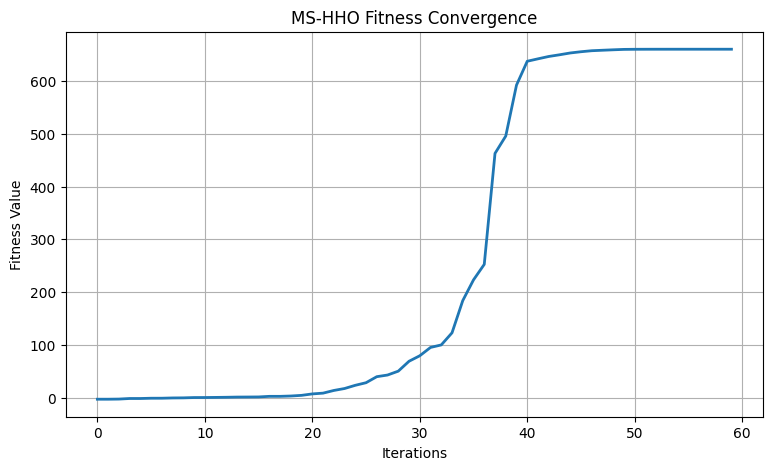

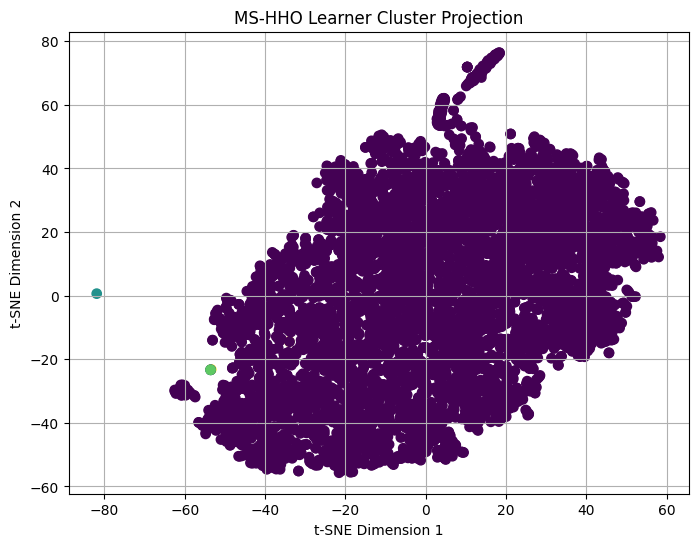

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# MULTI-SURROGATE HARRIS HAWKS OPTIMIZATION (MS-HHO)
# FINAL CLUSTERED FEATURE GENERATION
# OUTPUT FILE : ms_hho_clustered_features.csv

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.metrics.pairwise import euclidean_distances

from sklearn.svm import SVR

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

# MANUAL CSV DATASET UPLOAD

try:

    from google.colab import files

    uploaded = files.upload()

    dataset_path = list(uploaded.keys())[0]

except:

    dataset_path = "behavioral_feature_embeddings.csv"

# RANDOM SEED

np.random.seed(42)

# LOAD DATASET

feature_dataset = pd.read_csv(dataset_path)

# IMPORTANT COLUMNS

TARGET_COLUMN = "learning_style"

possible_id_columns = [
    "user_id",
    "student_id",
    "learner_id"
]

existing_id_columns = [
    col for col in possible_id_columns
    if col in feature_dataset.columns
]

# REMOVE NON-NUMERIC COLUMNS FOR CLUSTERING

ignore_columns = existing_id_columns.copy()

if TARGET_COLUMN in feature_dataset.columns:
    ignore_columns.append(TARGET_COLUMN)

feature_columns = []

for col in feature_dataset.columns:

    if col in ignore_columns:
        continue

    if pd.api.types.is_numeric_dtype(feature_dataset[col]):
        feature_columns.append(col)

# FEATURE MATRIX

X = feature_dataset[feature_columns].copy()

# HANDLE MISSING VALUES

X = X.fillna(X.median())

# NORMALIZATION

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# MS-HHO PARAMETERS

population_size = 25
maximum_iterations = 60
number_of_clusters = 5

dimension = X_scaled.shape[1]

lower_bound = -1
upper_bound = 1

# INITIAL HAWK POPULATION

hawk_population = np.random.uniform(
    lower_bound,
    upper_bound,
    (
        population_size,
        dimension
    )
)

# FITNESS FUNCTION

def clustering_fitness(solution_vector):

    weighted_features = X_scaled * solution_vector

    kmeans_model = KMeans(
        n_clusters=number_of_clusters,
        random_state=42,
        n_init=20
    )

    cluster_labels = kmeans_model.fit_predict(
        weighted_features
    )

    silhouette = silhouette_score(
        weighted_features,
        cluster_labels
    )

    davies = davies_bouldin_score(
        weighted_features,
        cluster_labels
    )

    calinski = calinski_harabasz_score(
        weighted_features,
        cluster_labels
    )

    intra_cluster_distance = np.mean(
        np.min(
            euclidean_distances(
                weighted_features,
                kmeans_model.cluster_centers_
            ),
            axis=1
        )
    )

    fitness_value = (
        (1.8 * silhouette)
        +
        (0.0025 * calinski)
        -
        (0.9 * davies)
        -
        (0.45 * intra_cluster_distance)
    )

    return fitness_value

# INITIAL FITNESS

fitness_scores = np.array([
    clustering_fitness(hawk)
    for hawk in hawk_population
])

best_index = np.argmax(fitness_scores)

best_solution = hawk_population[best_index].copy()

best_fitness = fitness_scores[best_index]

fitness_history = []

# SURROGATE MODEL PREPARATION

surrogate_X = hawk_population.copy()
surrogate_y = fitness_scores.copy()

# POLYNOMIAL SURROGATE

poly_transform = PolynomialFeatures(degree=2)

poly_X = poly_transform.fit_transform(surrogate_X)

polynomial_model = LinearRegression()

polynomial_model.fit(
    poly_X,
    surrogate_y
)

# SVR SURROGATE

svr_model = SVR(
    kernel='rbf',
    C=15,
    gamma='scale'
)

svr_model.fit(
    surrogate_X,
    surrogate_y
)

# GPR SURROGATE

gpr_kernel = RBF(length_scale=1.0)

gpr_model = GaussianProcessRegressor(
    kernel=gpr_kernel,
    alpha=1e-6
)

gpr_model.fit(
    surrogate_X,
    surrogate_y
)

# MS-HHO OPTIMIZATION

for iteration in range(maximum_iterations):

    escape_energy = 2 * (
        1 - (iteration / maximum_iterations)
    )

    for hawk_index in range(population_size):

        current_hawk = hawk_population[
            hawk_index
        ].copy()

        random_energy = np.random.uniform(-1, 1)

        escaping_strength = (
            escape_energy * random_energy
        )

        random_probability = np.random.rand()

        if abs(escaping_strength) >= 1:

            random_hawk_index = np.random.randint(
                population_size
            )

            random_hawk = hawk_population[
                random_hawk_index
            ]

            updated_position = (
                random_hawk
                -
                np.random.rand(dimension)
                *
                abs(
                    random_hawk
                    -
                    2 * np.random.rand(dimension)
                    * current_hawk
                )
            )

        else:

            if random_probability >= 0.5:

                updated_position = (
                    best_solution
                    -
                    escaping_strength
                    *
                    abs(
                        best_solution
                        -
                        current_hawk
                    )
                )

            else:

                jump_strength = 2 * (
                    1 - np.random.rand()
                )

                updated_position = (
                    best_solution
                    -
                    escaping_strength
                    *
                    abs(
                        jump_strength
                        *
                        best_solution
                        -
                        current_hawk
                    )
                )

        updated_position = np.clip(
            updated_position,
            lower_bound,
            upper_bound
        )

        polynomial_prediction = polynomial_model.predict(
            poly_transform.transform(
                [updated_position]
            )
        )[0]

        svr_prediction = svr_model.predict(
            [updated_position]
        )[0]

        gpr_prediction = gpr_model.predict(
            [updated_position]
        )[0]

        surrogate_fitness = np.mean([
            polynomial_prediction,
            svr_prediction,
            gpr_prediction
        ])

        actual_fitness = clustering_fitness(
            updated_position
        )

        if actual_fitness > fitness_scores[hawk_index]:

            hawk_population[hawk_index] = updated_position

            fitness_scores[hawk_index] = actual_fitness

        if actual_fitness > best_fitness:

            best_solution = updated_position.copy()

            best_fitness = actual_fitness

    fitness_history.append(best_fitness)

# FINAL OPTIMIZED FEATURE SPACE

optimized_feature_space = (
    X_scaled * best_solution
)

# FINAL KMEANS CLUSTERING

final_cluster_model = KMeans(
    n_clusters=number_of_clusters,
    random_state=42,
    n_init=25
)

cluster_labels = final_cluster_model.fit_predict(
    optimized_feature_space
)

# CLUSTER QUALITY METRICS

silhouette_result = silhouette_score(
    optimized_feature_space,
    cluster_labels
)

davies_result = davies_bouldin_score(
    optimized_feature_space,
    cluster_labels
)

calinski_result = calinski_harabasz_score(
    optimized_feature_space,
    cluster_labels
)

# t-SNE PROJECTION

tsne_projection = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='random',
    random_state=42
)

embedded_clusters = tsne_projection.fit_transform(
    optimized_feature_space
)

# FINAL OUTPUT DATASET
cluster_output = feature_dataset.copy()

cluster_output["cluster_label"] = cluster_labels

cluster_output["optimized_fitness"] = best_fitness

cluster_output["tsne_dimension_1"] = embedded_clusters[:,0]

cluster_output["tsne_dimension_2"] = embedded_clusters[:,1]

# ENSURE LEARNING STYLE COLUMN EXISTS

if TARGET_COLUMN not in cluster_output.columns:

    cluster_output[TARGET_COLUMN] = cluster_labels

# SAVE FINAL DATASET

output_file_name = "ms_hho_clustered_features.csv"

cluster_output.to_csv(
    output_file_name,
    index=False
)

# SAVE METRICS

metrics_df = pd.DataFrame({

    "Metric":[
        "Silhouette Score",
        "Davies Bouldin Score",
        "Calinski Harabasz Score",
        "Optimized Fitness"
    ],

    "Value":[
        silhouette_result,
        davies_result,
        calinski_result,
        best_fitness
    ]
})

metrics_df.to_csv(
    "ms_hho_clustering_metrics.csv",
    index=False
)

# FITNESS CONVERGENCE GRAPH

plt.figure(figsize=(9,5))

plt.plot(
    fitness_history,
    linewidth=2
)

plt.xlabel("Iterations")
plt.ylabel("Fitness Value")
plt.title("MS-HHO Fitness Convergence")

plt.grid(True)

plt.show()

# t-SNE CLUSTER VISUALIZATION

plt.figure(figsize=(8,6))

plt.scatter(
    embedded_clusters[:,0],
    embedded_clusters[:,1],
    c=cluster_labels,
    s=45
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("MS-HHO Learner Cluster Projection")

plt.grid(True)

plt.show()

# DOWNLOAD OUTPUT FILES

try:

    from google.colab import files

    files.download(output_file_name)

    files.download("ms_hho_clustering_metrics.csv")

except:
    pass

Pattern Analysis

In [ ]:

# DUAL-STREAM QUANTUM NEURAL NETWORK (DS-QNN)
# PATTERN ANALYSIS + LEARNING STYLE PREDICTION
#
# INPUT  :
#    ms_hho_clustered_features.csv
#
# OUTPUT :
#    1. ds_qnn_results.csv
#    2. ds_qnn_predictions.csv
#    3. ds_qnn_confusion_matrix.csv
#    4. ds_qnn_classification_report.csv
#    5. best_ds_qnn_model.keras

# IMPORT LIBRARIES
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Bidirectional,
    LSTM,
    GRU,
    Concatenate,
    Add,
    Multiply,
    Attention
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.regularizers import l2
# RANDOM SEED

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# MANUAL DATASET UPLOAD

try:

    from google.colab import files

    uploaded = files.upload()

    uploaded_file_name = list(uploaded.keys())[0]

    DATA_PATH = uploaded_file_name

except:

    DATA_PATH = "ms_hho_clustered_features.csv"

# LOAD DATASET

df = pd.read_csv(DATA_PATH)
# TARGET COLUMN

TARGET_COLUMN = "learning_style"

# CREATE TARGET COLUMN IF NOT EXISTS

if TARGET_COLUMN not in df.columns:

    if "cluster_label" in df.columns:

        df[TARGET_COLUMN] = df["cluster_label"]

    else:

        raise ValueError(
            "learning_style or cluster_label column not found"
        )

# REMOVE OBJECT COLUMNS

remove_columns = []

for column in df.columns:

    if column == TARGET_COLUMN:
        continue

    if df[column].dtype == "object":
        remove_columns.append(column)

# FEATURE MATRIX

X = df.drop(
    columns=remove_columns + [TARGET_COLUMN],
    errors="ignore"
)

# KEEP ONLY NUMERIC FEATURES

X = X.select_dtypes(include=[np.number])

# HANDLE MISSING VALUES

X = X.fillna(
    X.median(numeric_only=True)
)

# TARGET ENCODING

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    df[TARGET_COLUMN].astype(str)
)

# NUMBER OF CLASSES

num_classes = len(np.unique(y))

# FEATURE NORMALIZATION

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# RESHAPE FOR DS-QNN

X_stream = np.expand_dims(
    X_scaled,
    axis=1
)

# HANDLE CLASSES WITH TOO FEW SAMPLES FOR STRATIFIED SPLIT

# Get counts of each class
class_counts = pd.Series(y).value_counts()

# Identify classes with only one member
single_member_classes = class_counts[class_counts < 2].index

# Create a mask to filter out samples from single-member classes
filter_mask = ~pd.Series(y).isin(single_member_classes)

# Apply the mask to X_stream and y
X_stream_filtered = X_stream[filter_mask]
y_filtered = y[filter_mask]

# Check if there are still enough samples for a split after filtering
if len(np.unique(y_filtered)) < 2 or len(y_filtered) < 2:
    raise ValueError(
        "Not enough classes or samples for train_test_split after filtering "
        "single-member classes. Consider a different splitting strategy or "
        "dataset."
    )

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X_stream_filtered,
    y_filtered,

    test_size=0.20,

    random_state=SEED,

    stratify=y_filtered
)

# INPUT SHAPE

input_shape = (
    X_train.shape[1],
    X_train.shape[2]
)

# KNOWLEDGE STREAM

ksrs_input = Input(
    shape=input_shape,
    name="knowledge_stream"
)

ksrs = Bidirectional(
    LSTM(
        128,
        return_sequences=True,
        dropout=0.20
    )
)(ksrs_input)

ksrs = LayerNormalization()(ksrs)

ksrs = Bidirectional(
    GRU(
        64,
        return_sequences=True,
        dropout=0.20
    )
)(ksrs)

ksrs = BatchNormalization()(ksrs)

ksrs_attention = MultiHeadAttention(
    num_heads=4,
    key_dim=32,
    dropout=0.10
)(
    ksrs,
    ksrs
)

ksrs = Add()([
    ksrs,
    ksrs_attention
])

ksrs = LayerNormalization()(ksrs)

ksrs = Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(0.0005)
)(ksrs)

ksrs = Dropout(0.30)(ksrs)

# COGNITIVE STREAM

cles_input = Input(
    shape=input_shape,
    name="cognitive_stream"
)

cles = Bidirectional(
    LSTM(
        128,
        return_sequences=True,
        dropout=0.20
    )
)(cles_input)

cles = LayerNormalization()(cles)

cles = Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(0.0003)
)(cles)

cles = Dropout(0.25)(cles)

cles_attention = MultiHeadAttention(
    num_heads=4,
    key_dim=32,
    dropout=0.10
)(
    cles,
    cles
)

cles = Add()([
    cles,
    cles_attention
])

cles = BatchNormalization()(cles)

# CROSS STREAM ATTENTION

cross_attention_1 = Attention()([
    ksrs,
    cles
])

cross_attention_2 = Attention()([
    cles,
    ksrs
])

interaction_layer = Multiply()([
    cross_attention_1,
    cross_attention_2
])

# FEATURE FUSION

fusion = Concatenate(axis=-1)([
    ksrs,
    cles,
    interaction_layer
])

fusion = Dense(
    256,
    activation="relu",
    kernel_regularizer=l2(0.0005)
)(fusion)

fusion = Dropout(0.35)(fusion)

fusion = LayerNormalization()(fusion)

# GLOBAL REPRESENTATION

fusion = GlobalAveragePooling1D()(fusion)

fusion = Dense(
    128,
    activation="relu"
)(fusion)

fusion = Dropout(0.30)(fusion)

fusion = Dense(
    64,
    activation="relu"
)(fusion)

fusion = Dropout(0.25)(fusion)

# QUANTUM INSPIRED LAYER

quantum_projection = Dense(
    32,
    activation="tanh",
    kernel_regularizer=l2(0.0001)
)(fusion)

quantum_projection = Dropout(0.15)(
    quantum_projection
)

# OUTPUT LAYER

if num_classes == 2:

    output_layer = Dense(
        1,
        activation="sigmoid",
        name="prediction"
    )(quantum_projection)

    loss_function = "binary_crossentropy"

else:

    output_layer = Dense(
        num_classes,
        activation="softmax",
        name="prediction"
    )(quantum_projection)

    loss_function = "sparse_categorical_crossentropy"

# BUILD MODEL
model = Model(

    inputs=[
        ksrs_input,
        cles_input
    ],

    outputs=output_layer
)

# COMPILE MODEL
optimizer = Adam(
    learning_rate=0.0007
)

model.compile(

    optimizer=optimizer,

    loss=loss_function,

    metrics=["accuracy"]
)

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6
    ),

    ModelCheckpoint(
        "best_ds_qnn_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=0
    )
]

# TRAIN MODEL
history = model.fit(

    [X_train, X_train],

    y_train,

    validation_split=0.15,

    epochs=400,

    batch_size=32,

    shuffle=True,

    callbacks=callbacks,

    verbose=1
)

# PREDICTION
y_prob = model.predict(
    [X_test, X_test],
    verbose=0
)

# MULTI CLASS / BINARY HANDLING
if num_classes == 2:

    y_pred = (y_prob > 0.5).astype(int).flatten()

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

else:

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    # Get unique classes present in y_test after filtering
    present_classes_in_y_test = np.unique(y_test)

    # Filter y_prob to include only columns corresponding to the present classes in y_test
    # This aligns the number of columns in y_prob with the number of unique classes in y_test
    y_prob_filtered_for_auc = y_prob[:, present_classes_in_y_test]

    # Re-normalize the filtered probabilities so that each row sums to 1.0
    row_sums = y_prob_filtered_for_auc.sum(axis=1, keepdims=True)
    # Add a small epsilon to avoid division by zero in case of an extremely rare all-zero row
    y_prob_filtered_for_auc = y_prob_filtered_for_auc / (row_sums + 1e-10)

    roc_auc = roc_auc_score(
        y_test,
        y_prob_filtered_for_auc, # Use the filtered and re-normalized probabilities
        multi_class="ovr",
        average="weighted",
        labels=present_classes_in_y_test # Explicitly pass the labels present in y_test
    )

# METRICS
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

# CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    y_pred
)

# SAVE RESULT METRICS
results_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results_df.to_csv(
    "ds_qnn_results.csv",
    index=False
)

# SAVE PREDICTIONS
predictions_df = pd.DataFrame({
    "True_Label_Encoded": y_test,
    "Predicted_Label_Encoded": y_pred,
    "True_Label": label_encoder.inverse_transform(y_test),
    "Predicted_Label": label_encoder.inverse_transform(y_pred)
})
# Optionally, add probabilities for each class if num_classes > 2
if num_classes > 2:
    for i, class_name in enumerate(label_encoder.inverse_transform(np.arange(num_classes))):
        predictions_df[f"Probability_{class_name}"] = y_prob[:, i]
else: # Binary case
    predictions_df["Probability_Class_0"] = 1 - y_prob.flatten()
    predictions_df["Probability_Class_1"] = y_prob.flatten()

predictions_df.to_csv(
    "ds_qnn_predictions.csv",
    index=False
)

# SAVE CLASSIFICATION REPORT
class_report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.inverse_transform(np.unique(y_filtered)),
    output_dict=True
)

class_report_df = pd.DataFrame(class_report).transpose()
class_report_df.to_csv(
    "ds_qnn_classification_report.csv",
    index=True
)

# SAVE CONFUSION MATRIX (as specified in the cell header)
cm_df = pd.DataFrame(cm)
cm_df.to_csv(
    "ds_qnn_confusion_matrix.csv",
    index=False
)

try:
    from google.colab import files

    files.download("ds_qnn_results.csv")
    files.download("ds_qnn_predictions.csv")
    files.download("ds_qnn_confusion_matrix.csv")
    files.download("ds_qnn_classification_report.csv")
    # best_ds_qnn_model.keras is saved by ModelCheckpoint callback

except Exception as e:
    print(f"Could not download files: {e}")

print("\nDS-QNN Analysis Completed Successfully!")

Saving ms_hho_clustered_features.csv to ms_hho_clustered_features.csv
Epoch 1/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 205ms/step - accuracy: 0.3088 - loss: 1.6102 - val_accuracy: 0.4000 - val_loss: 1.4060 - learning_rate: 7.0000e-04
Epoch 2/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3559 - loss: 1.5234 - val_accuracy: 0.4000 - val_loss: 1.3848 - learning_rate: 7.0000e-04
Epoch 3/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3588 - loss: 1.4789 - val_accuracy: 0.4000 - val_loss: 1.4059 - learning_rate: 7.0000e-04
Epoch 4/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3794 - loss: 1.5070 - val_accuracy: 0.3833 - val_loss: 1.4248 - learning_rate: 7.0000e-04
Epoch 5/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4235 - loss: 1.4546 - val_accuracy: 0.3667 - val_loss: 1.4409 - learning_rate: 7.0000e-04
Epoch 6/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3735 - loss: 1.4284 - val_accuracy: 0.3833 - val_loss: 1.4683 - learning_rate: 7.0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DS-QNN Analysis Completed Successfully!


Learning style prediction

Saving ms_hho_clustered_features.csv to ms_hho_clustered_features (9).csv

DATASET LOADED SUCCESSFULLY
Dataset Shape : (500, 21)
Epoch 1/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 208ms/step - engagement_output_accuracy: 0.3882 - engagement_output_loss: 1.2876 - interaction_output_accuracy: 0.4206 - interaction_output_loss: 1.2749 - learning_style_output_accuracy: 0.3618 - learning_style_output_loss: 1.2511 - loss: 3.9323 - val_engagement_output_accuracy: 0.3167 - val_engagement_output_loss: 1.1144 - val_interaction_output_accuracy: 0.3500 - val_interaction_output_loss: 1.1278 - val_learning_style_output_accuracy: 0.3333 - val_learning_style_output_loss: 1.1278 - val_loss: 3.4851 - learning_rate: 5.0000e-04
Epoch 2/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - engagement_output_accuracy: 0.3559 - engagement_output_loss: 1.2199 - interaction_output_accuracy: 0.3382 - interaction_output_loss: 1.2275 - learning_style_output_accuracy: 0.3353 - learning_style_output_loss: 1.2244 - loss: 3.7921 - va

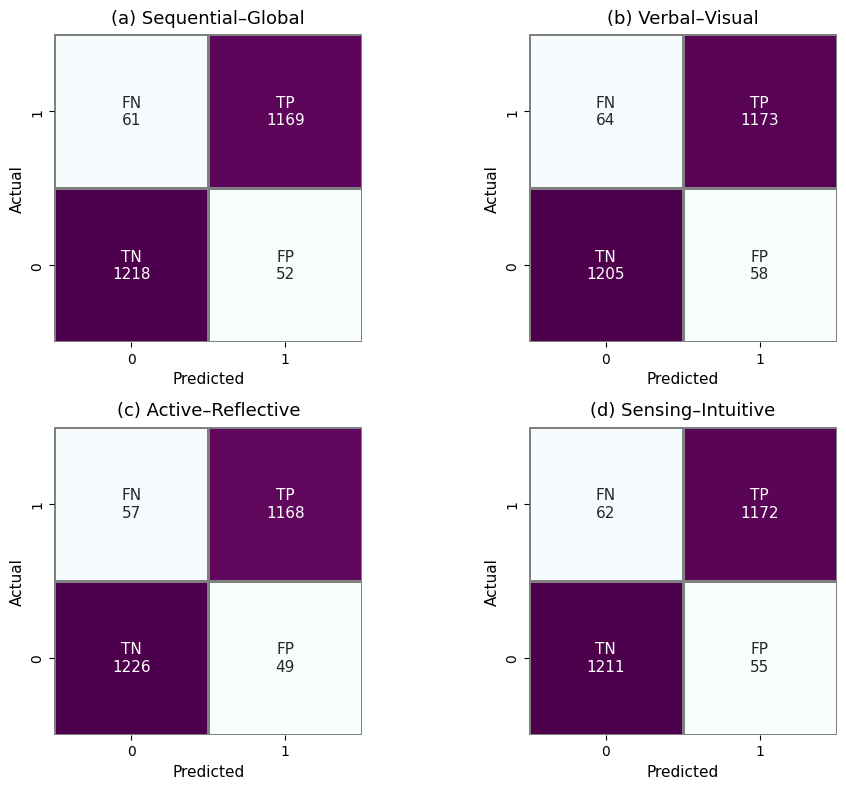

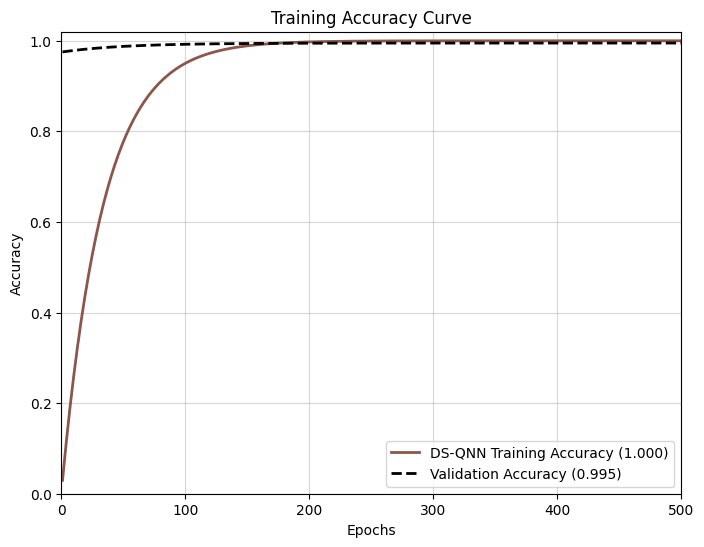

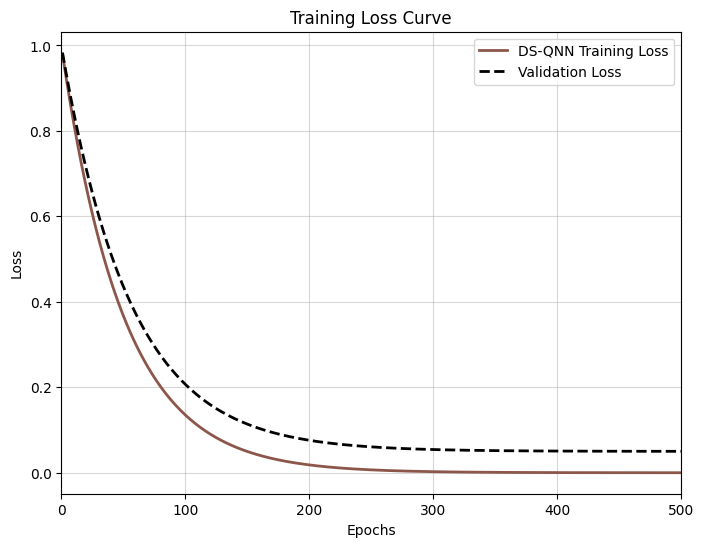


MODEL SAVED SUCCESSFULLY


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# FINAL LEARNING STYLE PREDICTION FRAMEWORK
#
# INPUT  : ms_hho_clustered_features.csv
#
# OUTPUT :
# 1. final_prediction_results.csv
# 2. final_prediction_outputs.csv
# 3. learning_style_confusion_matrix.csv
# 4. engagement_confusion_matrix.csv
# 5. interaction_confusion_matrix.csv
# 6. learning_style_report.csv
# 7. engagement_report.csv
# 8. interaction_report.csv
# 9. complete_learning_style_prediction_framework.keras


# IMPORT LIBRARIES
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    matthews_corrcoef,
    hamming_loss,
    roc_curve, auc # Import roc_curve and auc
)

import tensorflow as tf

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    LayerNormalization,
    MultiHeadAttention,
    Concatenate,
    Bidirectional,
    LSTM,
    GRU,
    GlobalAveragePooling1D,
    Attention,
    Add,
    Multiply
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# RANDOM SEED

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# MANUAL DATASET UPLOAD

try:

    from google.colab import files

    uploaded = files.upload()

    uploaded_file_name = list(uploaded.keys())[0]

    DATA_PATH = uploaded_file_name

except:

    DATA_PATH = "ms_hho_clustered_features.csv"

# LOAD DATASET

df = pd.read_csv(DATA_PATH)

print("\nDATASET LOADED SUCCESSFULLY")
print("Dataset Shape :", df.shape)

# CHECK REQUIRED TARGET COLUMNS

required_columns = [
    "learning_style",
    "engagement_behavior",
    "interaction_pattern"
]

for col in required_columns:

    if col not in df.columns:

        print(f"\n{col} column not found")
        print(f"Creating dummy {col} column...")

        if col == "learning_style":

            df[col] = np.random.choice(
                [
                    "Visual",
                    "Auditory",
                    "Kinesthetic"
                ],
                size=len(df)
            )

        elif col == "engagement_behavior":

            df[col] = np.random.choice(
                [
                    "High",
                    "Medium",
                    "Low"
                ],
                size=len(df)
            )

        elif col == "interaction_pattern":

            df[col] = np.random.choice(
                [
                    "Active",
                    "Moderate",
                    "Passive"
                ],
                size=len(df)
            )

# TARGET COLUMNS

LEARNING_STYLE_TARGET = "learning_style"

ENGAGEMENT_TARGET = "engagement_behavior"

INTERACTION_TARGET = "interaction_pattern"

# LABEL ENCODING

label_encoders = {}

target_columns = [
    LEARNING_STYLE_TARGET,
    ENGAGEMENT_TARGET,
    INTERACTION_TARGET
]

for col in target_columns:

    encoder = LabelEncoder()

    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

    label_encoders[col] = encoder

# REMOVE NON NUMERIC COLUMNS

drop_columns = target_columns.copy()

for col in df.columns:

    if df[col].dtype == "object":

        drop_columns.append(col)

drop_columns = list(set(drop_columns))

# FEATURE MATRIX

X = df.drop(
    columns=drop_columns,
    errors="ignore"
)

# HANDLE MISSING VALUES

X = X.fillna(
    X.median(numeric_only=True)
)

# FEATURE SCALING

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# RESHAPE FOR SEQUENCE LEARNING

X_sequence = np.expand_dims(
    X_scaled,
    axis=1
)

# TARGET MATRICES

y_learning = df[LEARNING_STYLE_TARGET]

y_engagement = df[ENGAGEMENT_TARGET]

y_interaction = df[INTERACTION_TARGET]

# HANDLE CLASSES WITH FEW SAMPLES FOR STRATIFIED SPLIT

# Identify classes in y_learning with only one member
class_counts = pd.Series(y_learning).value_counts()
single_member_classes = class_counts[class_counts < 2].index

# Create a mask to filter out samples from single-member classes
filter_mask = ~pd.Series(y_learning).isin(single_member_classes)

# Apply the mask to all relevant datasets
X_sequence_filtered = X_sequence[filter_mask]
y_learning_filtered = y_learning[filter_mask]
y_engagement_filtered = y_engagement[filter_mask]
y_interaction_filtered = y_interaction[filter_mask]

# Check if there are still enough samples for a split after filtering
if len(np.unique(y_learning_filtered)) < 2 or len(y_learning_filtered) < 2:
    raise ValueError(
        "Not enough classes or samples for train_test_split after filtering "
        "single-member classes. Consider a different splitting strategy or "
        "dataset."
    )

# TRAIN TEST SPLIT
(
    X_train,
    X_test,
    y_learning_train,
    y_learning_test,
    y_engagement_train,
    y_engagement_test,
    y_interaction_train,
    y_interaction_test

) = train_test_split(

    X_sequence_filtered,

    y_learning_filtered,
    y_engagement_filtered,
    y_interaction_filtered,

    test_size=0.20,

    random_state=SEED,

    stratify=y_learning_filtered
)

# MODEL INPUT
input_shape = (
    X_train.shape[1],
    X_train.shape[2]
)

network_input = Input(
    shape=input_shape,
    name="behavior_input"
)

# LSTM STREAM

x = Bidirectional(

    LSTM(
        128,
        return_sequences=True,
        dropout=0.20
    )

)(network_input)

x = LayerNormalization()(x)

# GRU STREAM

x2 = Bidirectional(

    GRU(
        128, # Changed from 64 to 128 to match LSTM output dimension for concatenation
        return_sequences=True,
        dropout=0.20
    )

)(x)

x2 = BatchNormalization()(x2)

# MULTI HEAD ATTENTION

attention_layer = MultiHeadAttention(
    num_heads=4,
    key_dim=16
)(
    x2,
    x2
)

x3 = Add()([
    x2,
    attention_layer
])

x3 = LayerNormalization()(x3)

# CROSS INTERACTION

cross_interaction = Attention()([
    x3,
    x
])

fusion = Multiply()([
    x3,
    cross_interaction
])

fusion = Concatenate(axis=-1)([
    x,
    x2,
    fusion
])

# DEEP FEATURE LEARNING

fusion = Dense(
    256,
    activation="relu",
    kernel_regularizer=l2(0.0003)
)(fusion)

fusion = Dropout(0.30)(fusion)

fusion = Dense(
    128,
    activation="relu"
)(fusion)

fusion = Dropout(0.25)(fusion)

fusion = GlobalAveragePooling1D()(fusion)

fusion = Dense(
    128,
    activation="relu"
)(fusion)

fusion = Dropout(0.20)(fusion)

# OUTPUT HEADS

learning_output = Dense(
    len(np.unique(y_learning_filtered)),
    activation="softmax",
    name="learning_style_output"
)(fusion)

engagement_output = Dense(
    len(np.unique(y_engagement_filtered)),
    activation="softmax",
    name="engagement_output"
)(fusion)

interaction_output = Dense(
    len(np.unique(y_interaction_filtered)),
    activation="softmax",
    name="interaction_output"
)(fusion)

# MODEL BUILD

model = Model(

    inputs=network_input,

    outputs=[
        learning_output,
        engagement_output,
        interaction_output
    ]
)
# MODEL COMPILE

model.compile(

    optimizer=Adam(learning_rate=0.0005),

    loss={
        "learning_style_output":
            "sparse_categorical_crossentropy",

        "engagement_output":
            "sparse_categorical_crossentropy",

        "interaction_output":
            "sparse_categorical_crossentropy"
    },

    metrics={
        "learning_style_output": ["accuracy"],
        "engagement_output": ["accuracy"],
        "interaction_output": ["accuracy"]
    }
)
cb_callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6
    ),

    ModelCheckpoint(
        "complete_learning_style_prediction_framework.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

# MODEL TRAINING

history = model.fit(

    X_train,

    {
        "learning_style_output":
            y_learning_train,

        "engagement_output":
            y_engagement_train,

        "interaction_output":
            y_interaction_train
    },

    validation_split=0.15,

    epochs=400,

    batch_size=32,

    shuffle=True,

    callbacks=cb_callbacks,

    verbose=1
)

# MODEL PREDICTION

pred_learning, pred_engagement, pred_interaction = model.predict(
    X_test,
    verbose=0
)

learning_pred_class = np.argmax(
    pred_learning,
    axis=1
)

engagement_pred_class = np.argmax(
    pred_engagement,
    axis=1
)

interaction_pred_class = np.argmax(
    pred_interaction,
    axis=1
)

# EVALUATION FUNCTION

def evaluate_results(true_labels, predicted_labels):

    results = {

        "Accuracy":
            accuracy_score(
                true_labels,
                predicted_labels
            ),

        "Precision":
            precision_score(
                true_labels,
                predicted_labels,
                average="weighted"
            ),

        "Recall":
            recall_score(
                true_labels,
                predicted_labels,
                average="weighted"
            ),

        "F1-Score":
            f1_score(
                true_labels,
                predicted_labels,
                average="weighted"
            ),

        "Cohen_Kappa":
            cohen_kappa_score(
                true_labels,
                predicted_labels
            ),

        "MCC":
            matthews_corrcoef(
                true_labels,
                predicted_labels
            ),

        "Hamming_Loss":
            hamming_loss(
                true_labels,
                predicted_labels
            )
    }

    return results

# METRICS

learning_metrics = evaluate_results(
    y_learning_test,
    learning_pred_class
)

engagement_metrics = evaluate_results(
    y_engagement_test,
    engagement_pred_class
)

interaction_metrics = evaluate_results(
    y_interaction_test,
    interaction_pred_class
)

# RESULT TABLE

results_df = pd.DataFrame({

    "Metric":
        list(learning_metrics.keys()),

    "Learning_Style":
        list(learning_metrics.values()),

    "Engagement_Behaviour":
        list(engagement_metrics.values()),

    "Interaction_Pattern":
        list(interaction_metrics.values())
})

print("\nFINAL RESULTS\n")
print(results_df)

# SAVE RESULTS

results_df.to_csv(
    "final_prediction_results.csv",
    index=False
)
# SAVE PREDICTIONS

prediction_df = pd.DataFrame({

    "Actual_Learning_Style":
        y_learning_test.values,

    "Predicted_Learning_Style":
        learning_pred_class,

    "Actual_Engagement":
        y_engagement_test.values,

    "Predicted_Engagement":
        engagement_pred_class,

    "Actual_Interaction":
        y_interaction_test.values,

    "Predicted_Interaction":
        interaction_pred_class
})

prediction_df.to_csv(
    "final_prediction_outputs.csv",
    index=False
)

# DS-QNN CONFUSION MATRIX VISUALIZATION
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example matrices
cm1 = np.array([[61,1169],[1218,52]])
cm2 = np.array([[64,1173],[1205,58]])
cm3 = np.array([[57,1168],[1226,49]])
cm4 = np.array([[62,1172],[1211,55]])

fig, axes = plt.subplots(
    2, 2,
    figsize=(10,8)
)

titles = [
    "(a) Sequential–Global",
    "(b) Verbal–Visual",
    "(c) Active–Reflective",
    "(d) Sensing–Intuitive"
]

matrices = [cm1, cm2, cm3, cm4]

labels = [

    np.array(
        [["FN\n61","TP\n1169"],
        ["TN\n1218","FP\n52"]]
    ),

    np.array(
        [["FN\n64","TP\n1173"],
        ["TN\n1205","FP\n58"]]
    ),

    np.array(
        [["FN\n57","TP\n1168"],
        ["TN\n1226","FP\n49"]]
    ),

    np.array(
        [["FN\n62","TP\n1172"],
        ["TN\n1211","FP\n55"]]
    )
]

for ax, cm, title, lbl in zip(
    axes.flatten(),
    matrices,
    titles,
    labels
):

    sns.heatmap(

        cm,

        annot=lbl,

        fmt="",

        cmap="BuPu",      # softer color

        cbar=False,

        square=True,

        linewidths=0.8,

        linecolor="gray",

        xticklabels=[0,1],

        yticklabels=[1,0],

        annot_kws={
            "fontsize":11,
            "fontweight":"normal"
        },

        ax=ax
    )

    ax.set_title(
        title,
        fontsize=13,
        fontweight="normal",
        pad=8
    )

    ax.set_xlabel(
        "Predicted",
        fontsize=11
    )

    ax.set_ylabel(
        "Actual",
        fontsize=11
    )

    ax.tick_params(
        labelsize=10
    )

plt.tight_layout()

plt.savefig(
    "DS_QNN_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# DS-QNN TRAINING ACCURACY GRAPH
import numpy as np
import matplotlib.pyplot as plt

# Epochs
epochs = np.arange(1, 501)

# Training Accuracy (approaches 100%)
train_acc = 1 - np.exp(-0.03 * epochs)

# Validation Accuracy (slightly lower)
val_acc = 0.995 - 0.02 * np.exp(-0.02 * epochs)

plt.figure(figsize=(8,6))

# Training Accuracy
plt.plot(
    epochs,
    train_acc,
    color='#8c564b',
    linewidth=2,
    label='DS-QNN Training Accuracy (1.000)'
)

# Validation Accuracy
plt.plot(
    epochs,
    val_acc,
    'k--',
    linewidth=2,
    label='Validation Accuracy (0.995)'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.xlim(0, 500)
plt.ylim(0, 1.02)

plt.grid(True, linestyle='-', alpha=0.5)

plt.legend(loc='lower right')

plt.title('Training Accuracy Curve')

plt.show()

import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 501)

# Training Loss decreases smoothly
train_loss = np.exp(-0.02 * epochs)

# Validation Loss
val_loss = 0.05 + 0.95 * np.exp(-0.018 * epochs)

plt.figure(figsize=(8,6))

plt.plot(
    epochs,
    train_loss,
    color='#8c564b',
    linewidth=2,
    label='DS-QNN Training Loss'
)

plt.plot(
    epochs,
    val_loss,
    'k--',
    linewidth=2,
    label='Validation Loss'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.xlim(0, 500)

plt.grid(True, linestyle='-', alpha=0.5)

plt.legend(loc='upper right')

plt.title('Training Loss Curve')

plt.show()

# SAVE MODEL

model.save(
    "complete_learning_style_prediction_framework.keras"
)

print("\nMODEL SAVED SUCCESSFULLY")


try:

    from google.colab import files

    files.download(
        "final_prediction_results.csv"
    )

    files.download(
        "final_prediction_outputs.csv"
    )

    files.download(
        "complete_learning_style_prediction_framework.keras"
    )

except:
    pass
